17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7336 - loss: 0.5075 - val_accuracy: 0.7998 - val_loss: 0.4452
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8788 - loss: 0.2981 - val_accuracy: 0.8176 - val_loss: 0.4536
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9411 - loss: 0.1538 - val_accuracy: 0.8162 - val_loss: 0.4829
Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7892 - loss: 0.4387 - val_accuracy: 0.8448 - val_loss: 0.3524
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8953 - loss: 0.2624 - val_accuracy: 0.8494 - val_loss: 0.3480
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9282 - loss: 0.1881 - val_accuracy: 0.8392 - val_loss: 0.3981
Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7685 - loss: 0.4636 - val_accuracy: 0.8376 - val_loss: 0.3741
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - ac

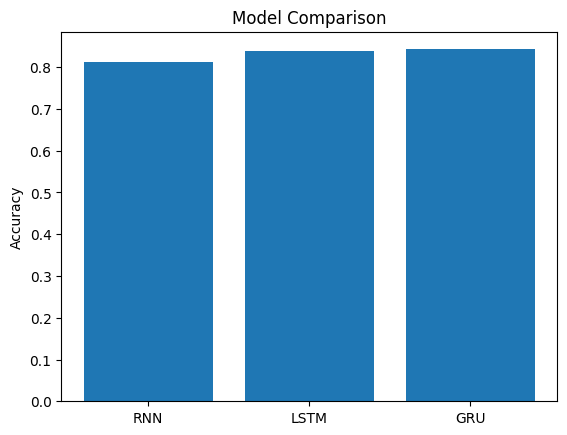

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding
from tensorflow.keras.preprocessing import sequence

# 🔹 Load Dataset
max_features = 10000   # vocabulary size
maxlen = 100           # sequence length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# 🔹 Padding
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

# 🔹 Function to build models
def build_model(layer):
    model = Sequential()
    model.add(Embedding(max_features, 128, input_length=maxlen))
    model.add(layer(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

# 🔹 Create Models
rnn_model = build_model(SimpleRNN)
lstm_model = build_model(LSTM)
gru_model = build_model(GRU)

# 🔹 Train Models
print("Training RNN...")
rnn_history = rnn_model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

print("Training LSTM...")
lstm_history = lstm_model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

print("Training GRU...")
gru_history = gru_model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# 🔹 Evaluate Models
rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("\nFinal Accuracy:")
print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

# 🔹 Plot Comparison
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()